# Experiment 5 - Does the memory model transfer across architectures?

Experiment 4 fit the memory model at one shape, 8L/512d/2048ff. At one shape it is a curve fit. It
is a model only if the slope decomposes into terms computable from the architecture:

    slope = 2 * n_layers * d_model * bytes      (KV cache - derivable)
          + per-token activation cost           (measured)

(`n_heads * head_dim == d_model` in `ModelConfig`, so the cache term collapses to this form.)

Three things must hold. The activation term should be **invariant in n_layers**, since per-layer
transients are freed as the stack runs; it should **rise with d_model and d_ff**; and it should be
**positive everywhere**, or the cache term is over-explaining the slope.

`arch_sweep.py` moves one axis at a time from the baseline and fits a slope at each shape from four
batch sizes. gpt2-small moves all three axes at once and is held out.

Source: `experiments/results/arch_sweep.json`. Memory only: seq_len 1024, batch varied to hit peaks
of 1.5-4.5 GB under a 9 GB budget, paged FP16 at `block_size` 16.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def results_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / 'experiments' / 'results').exists():
            return base / 'experiments' / 'results'
    raise FileNotFoundError('experiments/results not found from ' + str(Path.cwd()))


RESULTS = results_dir()
arch = pd.DataFrame(json.load(open(RESULTS / 'arch_sweep.json')))
arch['shape'] = (arch.n_layers.astype(str) + 'L/' + arch.d_model.astype(str) + 'd/'
                 + arch.d_ff.astype(str) + 'ff')

BASE = '8L/512d/2048ff'
HELD = '12L/768d/3072ff'      # gpt2-small

print(arch[['shape', 'n_layers', 'd_model', 'n_heads', 'd_ff',
            'slope_kb_per_token', 'intercept_mb', 'max_resid_mb']].to_string(index=False))
print(f'\nEvery shape is linear in resident tokens: worst residual {arch.max_resid_mb.max():.1f} MB '
      f'over a ~3 GB span (4 points each).')

          shape  n_layers  d_model  n_heads  d_ff  slope_kb_per_token  intercept_mb  max_resid_mb
 8L/512d/2048ff         8      512        8  2048              27.250         161.0          2.42
16L/512d/2048ff        16      512        8  2048              43.536         207.8          2.05
 4L/512d/2048ff         4      512        8  2048              19.134         135.9          1.83
8L/1024d/2048ff         8     1024       16  2048              46.530         335.6          0.70
 8L/512d/4096ff         8      512        8  4096              35.238         194.5          2.22
12L/768d/3072ff        12      768       12  3072              53.078         336.2          1.58

Every shape is linear in resident tokens: worst residual 2.4 MB over a ~3 GB span (4 points each).


## 1. Splitting the slope

In [2]:
arch['act_kb'] = arch.slope_kb_per_token - arch.predicted_cache_kb
arch['cache_pct'] = 100 * arch.predicted_cache_kb / arch.slope_kb_per_token

print(arch[['shape', 'slope_kb_per_token', 'predicted_cache_kb', 'act_kb', 'cache_pct']]
      .round(2).to_string(index=False))
print(f'\nThe activation residual is positive at every shape (min {arch.act_kb.min():.1f} '
      f'KB/token). Cache is {arch.cache_pct.min():.0f}-{arch.cache_pct.max():.0f}% of the slope.')

          shape  slope_kb_per_token  predicted_cache_kb  act_kb  cache_pct
 8L/512d/2048ff               27.25                16.0   11.25      58.72
16L/512d/2048ff               43.54                32.0   11.54      73.50
 4L/512d/2048ff               19.13                 8.0   11.13      41.81
8L/1024d/2048ff               46.53                32.0   14.53      68.77
 8L/512d/4096ff               35.24                16.0   19.24      45.41
12L/768d/3072ff               53.08                36.0   17.08      67.82

The activation residual is positive at every shape (min 11.1 KB/token). Cache is 42-74% of the slope.


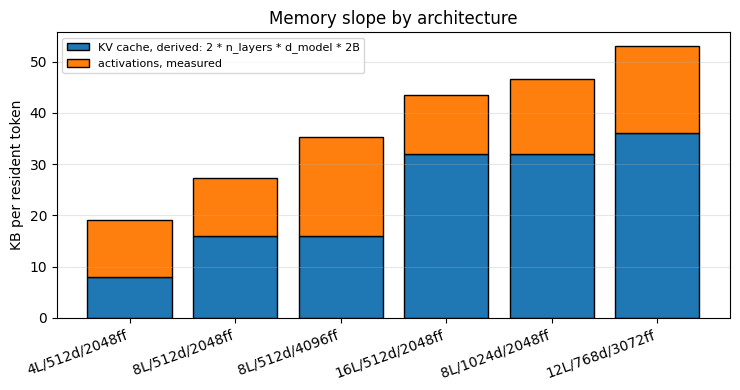

In [3]:
# Figure 1 - what the memory slope is made of.
order = arch.sort_values('slope_kb_per_token')
x = np.arange(len(order))

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(x, order.predicted_cache_kb, color='#1f77b4', edgecolor='black',
       label='KV cache, derived: 2 * n_layers * d_model * 2B')
ax.bar(x, order.act_kb, bottom=order.predicted_cache_kb, color='#ff7f0e', edgecolor='black',
       label='activations, measured')
ax.set_xticks(x, order['shape'], rotation=20, ha='right')
ax.set(ylabel='KB per resident token', title='Memory slope by architecture')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

## 2. The structural checks

Layers first: the cache term quadruples from 4L to 16L. If the activation residual followed it, the
split would be bookkeeping rather than structure.

In [4]:
layers = arch[(arch.d_model == 512) & (arch.d_ff == 2048)].sort_values('n_layers')
print(layers[['shape', 'n_layers', 'predicted_cache_kb', 'act_kb']].round(2).to_string(index=False))
spread = 100 * (layers.act_kb.max() - layers.act_kb.min()) / layers.act_kb.mean()
print(f'cache 4x, activations {spread:.1f}% - invariant in n_layers.\n')

base = arch[arch['shape'] == BASE].iloc[0]
for col, other in (('d_model', 'd_ff'), ('d_ff', 'd_model')):
    r = arch[(arch[col] != base[col]) & (arch[other] == base[other])
             & (arch.n_layers == base.n_layers)].iloc[0]
    print(f'{col} {base[col]} -> {r[col]}: activations {base.act_kb:.2f} -> {r.act_kb:.2f} '
          f'KB/token ({100 * (r.act_kb / base.act_kb - 1):+.0f}%)')

          shape  n_layers  predicted_cache_kb  act_kb
 4L/512d/2048ff         4                 8.0   11.13
 8L/512d/2048ff         8                16.0   11.25
16L/512d/2048ff        16                32.0   11.54
cache 4x, activations 3.6% - invariant in n_layers.

d_model 512 -> 1024: activations 11.25 -> 14.53 KB/token (+29%)
d_ff 2048 -> 4096: activations 11.25 -> 19.24 KB/token (+71%)


## 3. Predicting an unseen architecture

The checks license the smallest model with no `n_layers` term:

    activation KB/token = c0 + c1 * d_model + c2 * d_ff

fit on the three shapes that define those axes. Everything else is a prediction.

In [5]:
FIT_ON = [BASE, '8L/1024d/2048ff', '8L/512d/4096ff']
f = arch[arch['shape'].isin(FIT_ON)]
c0, c1, c2 = np.linalg.solve(np.column_stack([np.ones(len(f)), f.d_model, f.d_ff]), f.act_kb)
print(f'activations = {c0:+.3f} {c1:+.6f} * d_model {c2:+.6f} * d_ff'
      f'   (c0 is ~0: the residual is all width, no per-token floor)\n')

arch['pred_slope'] = arch.predicted_cache_kb + c0 + c1 * arch.d_model + c2 * arch.d_ff
arch['slope_err_pct'] = 100 * (arch.pred_slope - arch.slope_kb_per_token) / arch.slope_kb_per_token
arch['held_out'] = ~arch['shape'].isin(FIT_ON)

print(arch[['shape', 'held_out', 'slope_kb_per_token', 'pred_slope', 'slope_err_pct']]
      .round(2).to_string(index=False))
print(f'\nworst error on the {arch.held_out.sum()} held-out shapes: '
      f'{arch[arch.held_out].slope_err_pct.abs().max():.2f}%')

activations = -0.018 +0.006406 * d_model +0.003900 * d_ff   (c0 is ~0: the residual is all width, no per-token floor)

          shape  held_out  slope_kb_per_token  pred_slope  slope_err_pct
 8L/512d/2048ff     False               27.25       27.25           0.00
16L/512d/2048ff      True               43.54       43.25          -0.66
 4L/512d/2048ff      True               19.13       19.25           0.61
8L/1024d/2048ff     False               46.53       46.53           0.00
 8L/512d/4096ff     False               35.24       35.24           0.00
12L/768d/3072ff      True               53.08       52.88          -0.37

worst error on the 3 held-out shapes: 0.66%


## 4. Peak memory for gpt2-small, with nothing fitted on it

The slope comes from Section 3. The intercept is the token-independent part - weights, position
table, workspace - so predict it from the parameter count. `GPTModel` has an untied `lm_head`, so
the vocabulary matrix is paid for twice.

In [6]:
VOCAB, MAX_SEQ = 50257, 1024 + 8      # arch_sweep.py: SEQ_LEN + DECODE_LEN

params_mb = (2 * VOCAB * arch.d_model + MAX_SEQ * arch.d_model
             + arch.n_layers * (4 * arch.d_model ** 2 + 2 * arch.d_model * arch.d_ff)) * 2 / 1024**2
arch['params_mb'] = params_mb
arch['workspace_mb'] = arch.intercept_mb - arch.params_mb

print(arch[['shape', 'params_mb', 'intercept_mb', 'workspace_mb']].round(1).to_string(index=False))
print(f'\nParameter bytes explain the intercept to within '
      f'{arch.workspace_mb.min():.0f}-{arch.workspace_mb.max():.0f} MB. The remainder is small and '
      f'positive everywhere; treat it as a workspace constant, not a model.')

          shape  params_mb  intercept_mb  workspace_mb
 8L/512d/2048ff      147.2         161.0          13.8
16L/512d/2048ff      195.2         207.8          12.6
 4L/512d/2048ff      123.2         135.9          12.7
8L/1024d/2048ff      326.3         335.6           9.3
 8L/512d/4096ff      179.2         194.5          15.3
12L/768d/3072ff      310.7         336.2          25.5

Parameter bytes explain the intercept to within 9-25 MB. The remainder is small and positive everywhere; treat it as a workspace constant, not a model.


In [7]:
h = arch[arch['shape'] == HELD].iloc[0]
workspace = arch[~arch.held_out].workspace_mb.mean()
pred_icept = h.params_mb + workspace

t = np.array(h.tokens)
pred = h.pred_slope / 1024 * t + pred_icept
out = pd.DataFrame({'tokens': t, 'measured_mb': np.round(h.peaks, 1),
                    'predicted_mb': pred.round(1),
                    'error_pct': (100 * (pred - h.peaks) / np.array(h.peaks)).round(2)})

print(f'{HELD}: slope {h.pred_slope:.2f} KB/token, intercept {pred_icept:.0f} MB '
      f'(= {h.params_mb:.0f} params + {workspace:.0f} workspace)\n')
print(out.to_string(index=False))
print(f'\nworst error {out.error_pct.abs().max():.1f}%, with no parameter fitted on this shape.')

12L/768d/3072ff: slope 52.88 KB/token, intercept 324 MB (= 311 params + 13 workspace)

 tokens  measured_mb  predicted_mb  error_pct
  23552       1556.2        1539.9      -1.05
  41984       2513.9        2491.8      -0.88
  60416       3466.8        3443.7      -0.67
  77824       4370.2        4342.7      -0.63

worst error 1.1%, with no parameter fitted on this shape.


## 5. Summary

In [8]:
sweep = pd.read_csv(RESULTS / 'exp3_precision_sweep.csv')
sweep = sweep[sweep.status.eq('ok') & (sweep.cache_type == 'paged_fp16')]
exp4 = np.polyfit(sweep.seq_len * sweep.batch, sweep.peak_memory_mb, 1)[0] * 1024
exp5 = arch.loc[arch['shape'] == BASE, 'slope_kb_per_token'].iloc[0]

print(f'cache term : derived 2*L*d_model*2B holds at all {len(arch)} shapes, residual positive')
print(f'layers     : activations vary {spread:.1f}% while the cache term moves 4x')
print(f'width      : activations linear in d_model and d_ff, ~zero intercept')
print(f'held out   : slope within {arch[arch.held_out].slope_err_pct.abs().max():.2f}%, '
      f'full peak prediction for gpt2-small within {out.error_pct.abs().max():.1f}%')
print(f'replicated : baseline slope {exp5:.2f} vs {exp4:.2f} KB/token in Exp 3/4 '
      f'({100 * (exp5 - exp4) / exp4:+.2f}%, different script and harness path)')
print('\nThe memory model transfers: given (n_layers, d_model, d_ff, dtype, batch, seq_len) it')
print('predicts peak memory to ~1% on an architecture it has never seen.')

cache term : derived 2*L*d_model*2B holds at all 6 shapes, residual positive
layers     : activations vary 3.6% while the cache term moves 4x
width      : activations linear in d_model and d_ff, ~zero intercept
held out   : slope within 0.66%, full peak prediction for gpt2-small within 1.1%
replicated : baseline slope 27.25 vs 27.15 KB/token in Exp 3/4 (+0.36%, different script and harness path)

The memory model transfers: given (n_layers, d_model, d_ff, dtype, batch, seq_len) it
predicts peak memory to ~1% on an architecture it has never seen.


## Caveats

- Four points per shape - enough to rule out curvature of the size that would matter, not enough for
  a confidence interval on a slope. Residuals are quoted instead.
- `d_model` and `d_ff` each move by one doubling, so linearity in those axes is assumed and
  gpt2-small is its only test. A shape at 4x width could break it.
- `d_model` moves with `n_heads` (head_dim pinned at 64), so head count is not separated from width.
- The activation coefficients belong to this implementation - SDPA backend, this block code, FP16
  throughout. Re-fit with three shapes before using them elsewhere.
- Batch is chosen per shape to hit target peaks, so no two architectures are compared at an
  identical workload. Fine for a slope, not for a like-for-like memory comparison.
- The JSON records neither the GPU nor the commit.